# Import Dependcies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys
import functions

In [2]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

In [3]:
from utils import data_cleaning 
from models import A4_model
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.model_selection import cross_val_score

# Data Cleaning

In [4]:
full_path = os.path.join(parent_dir,  "data/bank_customers_train.csv")

df = pd.read_csv(full_path)
print(df.head())
print(len(df))
print(df.isnull().sum())


   age          job   marital          education default housing loan  \
0   35  blue-collar    single        high.school     NaN      no   no   
1   52  blue-collar   married                NaN     NaN     yes   no   
2   38     services   married        high.school     NaN      no   no   
3   44       admin.   married  university.degree      no     yes   no   
4   25     services  divorced           basic.4y      no     yes   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0   cellular   jul         thu  ...         3    999         0  nonexistent   
1  telephone   jun         thu  ...         4    999         0  nonexistent   
2  telephone   jun         tue  ...         2    999         0  nonexistent   
3  telephone   oct         wed  ...         1    999         0  nonexistent   
4  telephone   may         fri  ...         1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed    y  
0        

In [5]:
colums_missing_values = ['housing', 'loan', 'marital', 'education', 'job']
df = data_cleaning.drop_missing_values(df, colums_missing_values)
print(df.isnull().sum())
print(df.shape)

age                  0
job                  0
marital              0
education            0
default           7354
housing              0
loan                 0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
(36381, 21)


In [6]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[35 38 44 25 49 30 34 22 32 36 28 58 50 29 51 52 54 27 42 40 43 39 56 31
 69 75 45 81 33 41 26 53 47 48 46 37 73 21 59 55 72 23 63 60 57 83 74 85
 20 24 76 71 66 18 62 78 68 65 61 77 70 88 19 67 82 64 86 80 79 98 17 84
 94 95 87 91 89]

Unique values in job:
['blue-collar' 'services' 'admin.' 'technician' 'self-employed' 'retired'
 'unemployed' 'entrepreneur' 'management' 'housemaid' 'student']

Unique values in marital:
['single' 'married' 'divorced']

Unique values in education:
['high.school' 'university.degree' 'basic.4y' 'basic.6y' 'basic.9y'
 'professional.course' 'illiterate']

Unique values in default:
[nan 'no' 'yes']

Unique values in housing:
['no' 'yes']

Unique values in loan:
['no' 'yes']

Unique values in contact:
['cellular' 'telephone']

Unique values in month:
['jul' 'jun' 'oct' 'may' 'aug' 'sep' 'apr' 'nov' 'mar' 'dec']

Unique values in day_of_week:
['thu' 'tue' 'wed' 'fri' 'mon']

Unique values in duration:
[ 117  253  749 ... 1128 1970 2184]


# Feature Engineering

In [7]:
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous']
df = data_cleaning.scale_features(df, num_features)


# Binning Age into categories
age_bins = [0, 18, 30, 40, 50, 60, 100]  # Added 0 as minimum
age_labels = [0, 1, 2, 3, 4, 5]  # Added 0 for <18 if needed

df['age_bin'] = pd.cut(df['age'], 
                      bins=age_bins, 
                      labels=age_labels,
                      include_lowest=True)

# Frequency Encoding for 'job'
job_freq = df['job'].value_counts(normalize=True)
df['job_freq'] = df['job'].map(job_freq)


In [8]:
binary_mappings = {
    'default': {'no': 0, 'yes': 1, np.nan: -1},
    'housing': {'no': 0, 'yes': 1},
    'poutcome': {'failure': 0, 'success': 1, 'nonexistent': -1},
    'loan': {'no': 0, 'yes': 1},
    'y': {'no': 0, 'yes': 1}
}

df = data_cleaning.encode_categorical(
        df,
        label_encode_cols=['marital'],
        one_hot_encode_cols=['job', 'contact', 'month', 'day_of_week'],
        ordinal_encode_cols={'education': ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree']},
        binary_encode_cols= binary_mappings
    )

In [9]:
df['pdays'] = df['pdays'].replace(999, np.nan)

In [10]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[-0.47072165 -0.17865838  0.40546815 -1.44426589  0.89224027 -0.95749377
 -0.56807608 -1.73632915 -0.76278492 -0.37336723 -1.15220262  1.76843008
  0.98959469 -1.05484819  1.08694912  1.18430354  1.37901238 -1.24955704
  0.21075931  0.01605046  0.30811373 -0.08130396  1.57372123 -0.86013935
  2.83932873  3.42345527  0.50282258  4.00758181 -0.6654305   0.11340488
 -1.34691146  1.28165796  0.69753142  0.79488585  0.600177   -0.27601281
  3.22874642 -1.83368358  1.8657845   1.47636681  3.131392   -1.63897473
  2.25520219  1.96313892  1.67107565  4.20229066  3.32610085  4.3969995
 -1.931038   -1.54162031  3.52080969  3.03403758  2.54726546 -2.12574685
  2.15784777  3.71551854  2.74197431  2.44991104  2.06049335  3.61816412
  2.93668315  4.68906277 -2.02839242  2.64461989  4.10493623  2.35255662
  4.49435392  3.91022739  3.81287296  5.662607   -2.22310127  4.29964508
  5.27318931  5.37054373  4.59170835  4.98112604  4.78641719]

Unique values in marital:
[2 1 0]

Uniqu

In [11]:
risk_score = (
    df['default'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['housing'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['loan'].apply(lambda x: 1 if x == 'yes' else 0)
)

In [12]:
print(df.dtypes)
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

age                   float64
marital                 int64
education             float64
default                 int64
housing                 int64
loan                    int64
duration              float64
campaign              float64
pdays                 float64
previous              float64
poutcome                int64
emp.var.rate          float64
cons.price.idx        float64
cons.conf.idx         float64
euribor3m             float64
nr.employed           float64
y                       int64
age_bin              category
job_freq              float64
job_blue-collar          bool
job_entrepreneur         bool
job_housemaid            bool
job_management           bool
job_retired              bool
job_self-employed        bool
job_services             bool
job_student              bool
job_technician           bool
job_unemployed           bool
contact_telephone        bool
month_aug                bool
month_dec                bool
month_jul                bool
month_jun 

<Axes: >

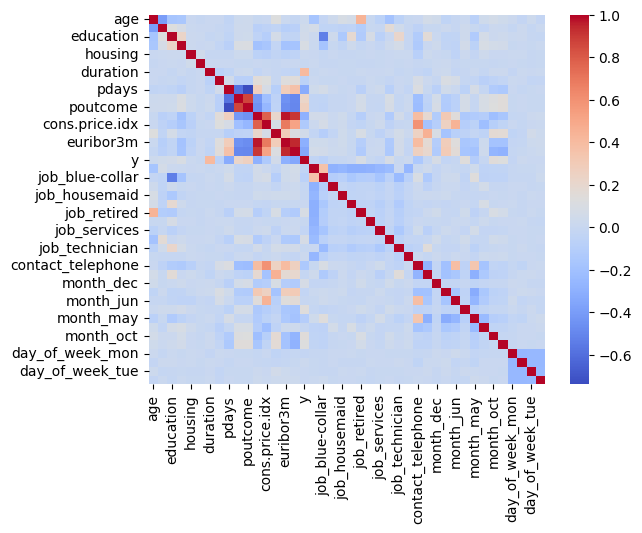

In [13]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

# Predicting Customer Conversion (Yes/No) - Classification

In [14]:
print(df.columns)
print(df['age_bin'].isnull().sum())

Index(['age', 'marital', 'education', 'default', 'housing', 'loan', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'age_bin', 'job_freq', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed'],
      dtype='object')
20285


## Logistic Regression

In [15]:
X = df.drop(columns=['y', 'age_bin'])  # Features
y = df['y']  # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Logistic Regression works better with normalized data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Find the best Logistic Regression model parameters
best_model = A4_model.find_best_logistic_regression_params(X_train, y_train)

# 5. Train and evaluate the model
y_test_result, y_pred = A4_model.train_and_evaluate_logistic_regression(best_model, X_train, y_train, X_test, y_test)

Best Parameters: {'C': np.float64(73.92266140516048), 'penalty': 'l1', 'solver': 'liblinear'}
Test Accuracy: 0.9113645733131785
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      6472
           1       0.64      0.45      0.53       805

    accuracy                           0.91      7277
   macro avg       0.79      0.71      0.74      7277
weighted avg       0.90      0.91      0.90      7277



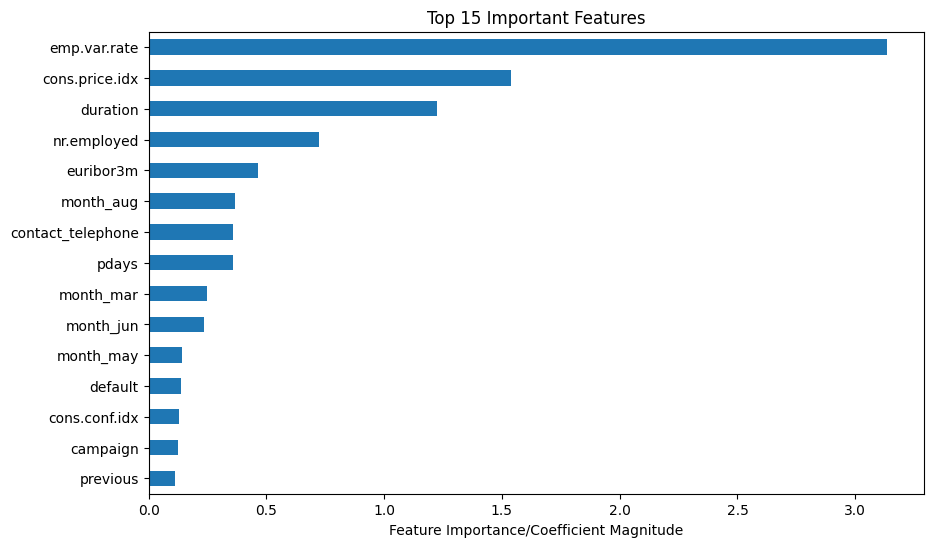

In [16]:
functions.plot_top_features(best_model, X)

## Random Forest

In [17]:
best_rf = A4_model.find_best_random_forest_params(X_train, y_train)
y_pred, y_proba, cv_accuracy = A4_model.train_and_evaluate_random_forest(best_rf, X_train, y_train, X_test, y_test)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced'}
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      6472
           1       0.50      0.88      0.63       805

    accuracy                           0.89      7277
   macro avg       0.74      0.88      0.78      7277
weighted avg       0.93      0.89      0.90      7277

ROC-AUC Score: 0.948
Cross-Validation Accuracy: 0.887


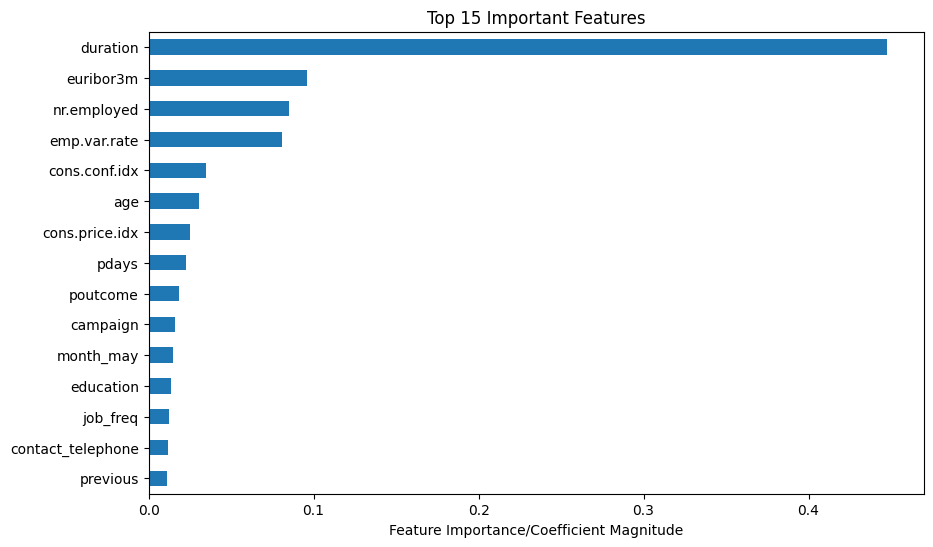

In [18]:
functions.plot_top_features(best_rf, X) 